# Recurrent Neural Networks

## Learning Objectives

1. **Explain** why feedforward networks fail on sequential data: fixed-length input, no memory
2. **Define** the RNN update equations: $s_t = f(Ux_t + Ws_{t-1} + b)$, $y_t = g(Vs_t + c)$
3. **Derive** Backpropagation Through Time (BPTT): the recurrence $R_t = P_t + Q_t R_{t-1}$
4. **Prove** why gradients vanish/explode: product of matrices $\prod_{k} Q_k$ across time steps
5. **Describe** the three RNN usage patterns: one-to-one, one-to-many, many-to-many
6. **Implement** a character-level RNN from scratch


## Problem Statement

Sequential data — text, speech, time series — has variable length and temporal dependencies. A feedforward network requires fixed-length inputs and cannot model long-range dependencies across time steps.

### RNN Architecture

A **Recurrent Neural Network** maintains a **hidden state** $s_t$ that summarises the sequence so far:

$$s_t = f(U x_t + W s_{t-1} + \mathbf{b}), \quad s_0 = \mathbf{0}$$
$$y_t = g(V s_t + \mathbf{c})$$

where:
- $x_t \in \mathbb{R}^d$: input at time $t$
- $s_t \in \mathbb{R}^m$: hidden state ("memory")
- $y_t \in \mathbb{R}^k$: output at time $t$
- $U \in \mathbb{R}^{m \times d}$, $W \in \mathbb{R}^{m \times m}$, $V \in \mathbb{R}^{k \times m}$: weight matrices (shared across time)
- $f$: hidden activation (typically $\tanh$); $g$: output activation (softmax for classification)

Parameters are **shared** across all time steps — the same $U, W, V$ are used at every $t$.

### Vanishing/Exploding Gradients

BPTT computes $\partial L / \partial s_0$ by backpropagating through all $T$ time steps. The gradient involves a product of $T$ Jacobian matrices $\partial s_t / \partial s_{t-1}$. If the dominant singular value $\sigma_1 < 1$, gradients decay as $\sigma_1^T \to 0$ (vanishing); if $\sigma_1 > 1$, they grow as $\sigma_1^T \to \infty$ (exploding).


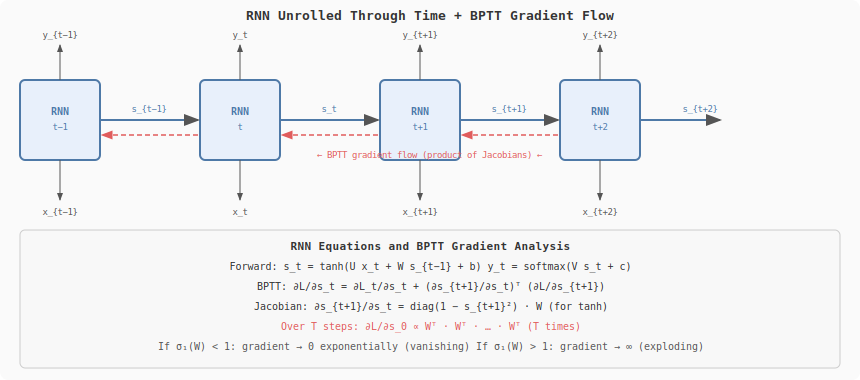

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="380" font-family="monospace" font-size="11">
  <rect width="860" height="380" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#555"/></marker>
        <marker id="red" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#e05c5c"/></marker></defs>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">RNN Unrolled Through Time + BPTT Gradient Flow</text>

  <!-- RNN cells at t-1, t, t+1, t+2 -->
  <!-- Cell at t-1 -->
  <rect x="20"  y="80" width="80" height="80" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="2"/>
  <text x="60"  y="115" text-anchor="middle" fill="#4e79a7" font-size="10" font-weight="bold">RNN</text>
  <text x="60"  y="130" text-anchor="middle" fill="#4e79a7" font-size="9">t−1</text>
  <!-- x_{t-1} -->
  <line x1="60" y1="160" x2="60" y2="200" stroke="#555" marker-end="url(#arr)"/>
  <text x="60" y="215" text-anchor="middle" fill="#555" font-size="9">x_{t−1}</text>
  <!-- y_{t-1} -->
  <line x1="60" y1="80" x2="60" y2="45"  stroke="#555" marker-end="url(#arr)"/>
  <text x="60" y="38" text-anchor="middle" fill="#555" font-size="9">y_{t−1}</text>

  <!-- Cell at t -->
  <rect x="200" y="80" width="80" height="80" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="2"/>
  <text x="240" y="115" text-anchor="middle" fill="#4e79a7" font-size="10" font-weight="bold">RNN</text>
  <text x="240" y="130" text-anchor="middle" fill="#4e79a7" font-size="9">t</text>
  <line x1="240" y1="160" x2="240" y2="200" stroke="#555" marker-end="url(#arr)"/>
  <text x="240" y="215" text-anchor="middle" fill="#555" font-size="9">x_t</text>
  <line x1="240" y1="80" x2="240" y2="45" stroke="#555" marker-end="url(#arr)"/>
  <text x="240" y="38" text-anchor="middle" fill="#555" font-size="9">y_t</text>

  <!-- Cell at t+1 -->
  <rect x="380" y="80" width="80" height="80" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="2"/>
  <text x="420" y="115" text-anchor="middle" fill="#4e79a7" font-size="10" font-weight="bold">RNN</text>
  <text x="420" y="130" text-anchor="middle" fill="#4e79a7" font-size="9">t+1</text>
  <line x1="420" y1="160" x2="420" y2="200" stroke="#555" marker-end="url(#arr)"/>
  <text x="420" y="215" text-anchor="middle" fill="#555" font-size="9">x_{t+1}</text>
  <line x1="420" y1="80" x2="420" y2="45" stroke="#555" marker-end="url(#arr)"/>
  <text x="420" y="38" text-anchor="middle" fill="#555" font-size="9">y_{t+1}</text>

  <!-- Cell at t+2 -->
  <rect x="560" y="80" width="80" height="80" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="2"/>
  <text x="600" y="115" text-anchor="middle" fill="#4e79a7" font-size="10" font-weight="bold">RNN</text>
  <text x="600" y="130" text-anchor="middle" fill="#4e79a7" font-size="9">t+2</text>
  <line x1="600" y1="160" x2="600" y2="200" stroke="#555" marker-end="url(#arr)"/>
  <text x="600" y="215" text-anchor="middle" fill="#555" font-size="9">x_{t+2}</text>
  <line x1="600" y1="80" x2="600" y2="45" stroke="#555" marker-end="url(#arr)"/>
  <text x="600" y="38" text-anchor="middle" fill="#555" font-size="9">y_{t+2}</text>

  <!-- Horizontal state arrows (forward) -->
  <line x1="100" y1="120" x2="198" y2="120" stroke="#4e79a7" stroke-width="2" marker-end="url(#arr)"/>
  <text x="149" y="112" text-anchor="middle" fill="#4e79a7" font-size="9">s_{t−1}</text>
  <line x1="280" y1="120" x2="378" y2="120" stroke="#4e79a7" stroke-width="2" marker-end="url(#arr)"/>
  <text x="329" y="112" text-anchor="middle" fill="#4e79a7" font-size="9">s_t</text>
  <line x1="460" y1="120" x2="558" y2="120" stroke="#4e79a7" stroke-width="2" marker-end="url(#arr)"/>
  <text x="509" y="112" text-anchor="middle" fill="#4e79a7" font-size="9">s_{t+1}</text>
  <line x1="640" y1="120" x2="720" y2="120" stroke="#4e79a7" stroke-width="2" marker-end="url(#arr)"/>
  <text x="700" y="112" text-anchor="middle" fill="#4e79a7" font-size="9">s_{t+2}</text>

  <!-- BPTT backward arrows (red dashed) -->
  <line x1="558" y1="135" x2="462" y2="135" stroke="#e05c5c" stroke-width="1.5" stroke-dasharray="5,3" marker-end="url(#red)"/>
  <line x1="378" y1="135" x2="282" y2="135" stroke="#e05c5c" stroke-width="1.5" stroke-dasharray="5,3" marker-end="url(#red)"/>
  <line x1="198" y1="135" x2="102" y2="135" stroke="#e05c5c" stroke-width="1.5" stroke-dasharray="5,3" marker-end="url(#red)"/>
  <text x="430" y="158" text-anchor="middle" fill="#e05c5c" font-size="9">← BPTT gradient flow (product of Jacobians) ←</text>

  <!-- Equations -->
  <rect x="20" y="230" width="820" height="138" rx="5" fill="#f8f8f8" stroke="#ccc"/>
  <text x="430" y="250" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">RNN Equations and BPTT Gradient Analysis</text>
  <text x="430" y="270" text-anchor="middle" fill="#333" font-size="10">Forward:  s_t = tanh(U x_t + W s_{t−1} + b)     y_t = softmax(V s_t + c)</text>
  <text x="430" y="290" text-anchor="middle" fill="#333" font-size="10">BPTT:  ∂L/∂s_t = ∂L_t/∂s_t + (∂s_{t+1}/∂s_t)ᵀ (∂L/∂s_{t+1})</text>
  <text x="430" y="310" text-anchor="middle" fill="#333" font-size="10">Jacobian:  ∂s_{t+1}/∂s_t = diag(1 − s_{t+1}²) · W   (for tanh)</text>
  <text x="430" y="330" text-anchor="middle" fill="#e05c5c" font-size="10">Over T steps:  ∂L/∂s_0 ∝ Wᵀ · Wᵀ · … · Wᵀ   (T times)</text>
  <text x="430" y="350" text-anchor="middle" fill="#555" font-size="10">If σ₁(W) &lt; 1:  gradient → 0 exponentially  (vanishing)     If σ₁(W) &gt; 1:  gradient → ∞  (exploding)</text>
</svg>
'''
display(SVG(svg))


## Derivation

### BPTT Recurrence

Total loss: $L = \sum_{t=1}^T L_t(y_t, \hat{y}_t)$

Define $R_t = \partial L / \partial s_t$. At time $T$: $R_T = \partial L_T / \partial s_T$.

For $t < T$:
$$R_t = \underbrace{\frac{\partial L_t}{\partial s_t}}_{P_t} + \underbrace{\frac{\partial s_{t+1}}{\partial s_t}^\top}_{Q_t^\top} R_{t+1}$$

where:
- $P_t = V^\top \partial L_t / \partial y_t$ — direct loss gradient from output at time $t$
- $Q_t = \partial s_{t+1}/\partial s_t = \text{diag}(1 - s_{t+1}^2) \cdot W$ (for $\tanh$)

Expanding: $R_0 = P_0 + Q_0^\top (P_1 + Q_1^\top (P_2 + \ldots))$. The gradient of $L_T$ w.r.t. $s_0$ passes through $\prod_{k=0}^{T-1} Q_k^\top$.

### Vanishing Gradient Analysis

If $\|Q_t\| = \|\text{diag}(1-s^2) W\| \leq \gamma < 1$ for all $t$, then $\|\prod Q_k\| \leq \gamma^T \to 0$ exponentially.

Since $\tanh' \in (0,1]$ and $\tanh'(z) \approx 0$ for large $|z|$, and weight matrices typically have spectral norm near 1, vanishing gradients are almost inevitable for long sequences.

**Practical fixes:**
- **Gradient clipping**: if $\|g\| > \tau$, scale $g \leftarrow \tau g / \|g\|$ (handles exploding)
- **LSTM/GRU**: gating mechanisms that allow gradients to flow directly through time (see `ml_013_06`)
- **Truncated BPTT**: backpropagate only $k$ steps (reduces but doesn't eliminate the problem)


In [2]:
import numpy as np


class CharRNN:
    """
    Character-level RNN: given a sequence of characters, predict the next character.
    Uses tanh hidden activation and softmax output.
    """

    def __init__(self, vocab_size, hidden_size, lr=0.01, seed=0):
        rng = np.random.default_rng(seed)
        self.V = vocab_size
        self.H = hidden_size
        self.lr = lr
        scale = 0.01
        self.U = rng.normal(0, scale, (hidden_size, vocab_size))   # input → hidden
        self.W = rng.normal(0, scale, (hidden_size, hidden_size))  # hidden → hidden
        self.b = np.zeros(hidden_size)
        self.Wout = rng.normal(0, scale, (vocab_size, hidden_size)) # hidden → output
        self.c    = np.zeros(vocab_size)

    def _softmax(self, a):
        e = np.exp(a - a.max()); return e / e.sum()

    def forward(self, x_indices, s_prev):
        """Returns list of (s_t, y_t) for each time step."""
        states, outputs = [], []
        s = s_prev
        for x_idx in x_indices:
            x = np.zeros(self.V); x[x_idx] = 1.0
            s = np.tanh(self.U @ x + self.W @ s + self.b)
            y = self._softmax(self.Wout @ s + self.c)
            states.append(s)
            outputs.append(y)
        return states, outputs

    def loss(self, targets, outputs):
        return -sum(np.log(outputs[t][targets[t]] + 1e-12)
                    for t in range(len(targets)))

    def backward(self, x_indices, targets, states, outputs, s_prev):
        """BPTT. Returns gradients for all parameters."""
        T = len(x_indices)
        dU = np.zeros_like(self.U)
        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        dWout = np.zeros_like(self.Wout)
        dc    = np.zeros_like(self.c)
        ds_next = np.zeros(self.H)

        for t in reversed(range(T)):
            # Output gradient
            dy = outputs[t].copy()
            dy[targets[t]] -= 1.0   # softmax + CE gradient
            dWout += np.outer(dy, states[t])
            dc    += dy

            # Hidden gradient
            ds = self.Wout.T @ dy + ds_next
            dtanh = (1 - states[t]**2) * ds   # tanh prime

            db += dtanh
            s_prev_t = states[t-1] if t > 0 else s_prev
            dW += np.outer(dtanh, s_prev_t)
            x = np.zeros(self.V); x[x_indices[t]] = 1.0
            dU += np.outer(dtanh, x)
            ds_next = self.W.T @ dtanh

        # Gradient clipping
        for g in [dU, dW, db, dWout, dc]:
            np.clip(g, -5, 5, out=g)

        return dU, dW, db, dWout, dc

    def step(self, grads):
        dU, dW, db, dWout, dc = grads
        self.U    -= self.lr * dU
        self.W    -= self.lr * dW
        self.b    -= self.lr * db
        self.Wout -= self.lr * dWout
        self.c    -= self.lr * dc

    def sample(self, seed_idx, n=50):
        """Generate n characters starting from seed."""
        s = np.zeros(self.H)
        result = [seed_idx]
        for _ in range(n-1):
            x = np.zeros(self.V); x[result[-1]] = 1.0
            s = np.tanh(self.U @ x + self.W @ s + self.b)
            y = self._softmax(self.Wout @ s + self.c)
            result.append(np.random.choice(self.V, p=y))
        return result


# ── Train on a small repeated pattern ────────────────────────────────────────
text   = "hello world " * 200
vocab  = sorted(set(text))
ch2idx = {c: i for i, c in enumerate(vocab)}
idx2ch = {i: c for c, i in ch2idx.items()}
data   = [ch2idx[c] for c in text]

rnn = CharRNN(vocab_size=len(vocab), hidden_size=32, lr=0.05)
seq_len = 20
n_iters = 2000
losses  = []

for i in range(n_iters):
    pos = (i * seq_len) % (len(data) - seq_len - 1)
    xs  = data[pos : pos + seq_len]
    ys  = data[pos+1 : pos + seq_len + 1]
    s0  = np.zeros(rnn.H)
    states, outputs = rnn.forward(xs, s0)
    loss = rnn.loss(ys, outputs)
    grads = rnn.backward(xs, ys, states, outputs, s0)
    rnn.step(grads)
    if i % 200 == 0:
        losses.append(loss)
        sampled = ''.join(idx2ch[c] for c in rnn.sample(xs[0]))
        print(f"iter {i:4d}: loss={loss:.2f}  sample='{sampled[:30]}'")

print(f"\nFinal loss: {losses[-1]:.2f}")


iter    0: loss=41.59  sample='hrd ldh ehlw ldorr hhlrrhwh  r'
iter  200: loss=7.88  sample='ello world wello hello horlo h'
iter  400: loss=0.30  sample=' hello worhd hellorworld hello'


iter  600: loss=5.89  sample='ld hello worlo wo horwo worlel'
iter  800: loss=0.42  sample='d hello world helld world herl'
iter 1000: loss=11.74  sample='rld hello lorld hello wo wd ho'


iter 1200: loss=3.91  sample='world hello world hello hello '
iter 1400: loss=0.23  sample='orld hello world hello world h'
iter 1600: loss=9.31  sample=' horld hello wello wello wello'


iter 1800: loss=0.49  sample='lo world hello world hello wor'

Final loss: 0.49
